# Google Play Store EDA Project

## Objective
Analyze the Google Play Store dataset to understand app ratings, installs, pricing, categories, and user engagement.

# *Google Play Store dataset*

**lets gooooooooooooooooooooooo*

In [1]:
# import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
#fetch the dataset
data = pd.read_csv('googleplaystore.csv')

## Understand the basics related to dataset

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
display(data.head())

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [9]:
data.isnull().sum()

,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


### **What is the shape of the dataset?*

In [10]:
print(data.shape)

(10841, 13)


What are the data types of all columns? and Find out the name of all the columns

In [11]:
print(data.columns)

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')


Which columns contain missing values?

In [15]:
duplicate_apps = data['App'].value_counts()
duplicate_apps = duplicate_apps[duplicate_apps > 1]
print(duplicate_apps)

App
ROBLOX                                               9
CBS Sports App - Scores, News, Stats & Watch Live    8
8 Ball Pool                                          7
Candy Crush Saga                                     7
ESPN                                                 7
                                                    ..
Android Messages                                     2
Google Duo - High Quality Video Calls                2
WPS Office - Word, Docs, PDF, Note, Slide & Sheet    2
Flickr                                               2
Chrome Dev                                           2
Name: count, Length: 798, dtype: int64


What percentage of values are missing in each column?

In [12]:
data.isnull().sum() / len(data) * 100

,0
App,0.000000
Category,0.000000
Rating,13.596532
Reviews,0.000000
Size,0.000000
Installs,0.000000
Type,0.009224
Price,0.000000
Content Rating,0.009224
Genres,0.000000


Find out the numerical  columns and categorical columns separately

In [13]:
numerical_cols = data.select_dtypes(include=np.number).columns.tolist()
categorical_cols = data.select_dtypes(include='object').columns.tolist()

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['Rating']
Categorical Columns: ['App', 'Category', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


How many duplicate rows exist?

In [14]:
print(data.duplicated().sum())

483


Which apps appear more than once?

In [17]:
duplicate_apps = data[data.duplicated(subset='App', keep=False)].sort_values('App')

print("Number of duplicate app entries:", duplicate_apps.shape[0])

duplicate_apps

Number of duplicate app entries: 1979


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
1393,10 Best Foods for You,HEALTH_AND_FITNESS,4.0,2490,3.8M,"500,000+",Free,0,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up
1407,10 Best Foods for You,HEALTH_AND_FITNESS,4.0,2490,3.8M,"500,000+",Free,0,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up
2543,1800 Contacts - Lens Store,MEDICAL,4.7,23160,26M,"1,000,000+",Free,0,Everyone,Medical,"July 27, 2018",7.4.1,5.0 and up
2322,1800 Contacts - Lens Store,MEDICAL,4.7,23160,26M,"1,000,000+",Free,0,Everyone,Medical,"July 27, 2018",7.4.1,5.0 and up
2385,2017 EMRA Antibiotic Guide,MEDICAL,4.4,12,3.8M,"1,000+",Paid,$16.99,Everyone,Medical,"January 27, 2017",1.0.5,4.0.3 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3202,trivago: Hotels & Travel,TRAVEL_AND_LOCAL,4.2,219848,Varies with device,"50,000,000+",Free,0,Everyone,Travel & Local,"August 2, 2018",Varies with device,Varies with device
3118,trivago: Hotels & Travel,TRAVEL_AND_LOCAL,4.2,219848,Varies with device,"50,000,000+",Free,0,Everyone,Travel & Local,"August 2, 2018",Varies with device,Varies with device
3103,trivago: Hotels & Travel,TRAVEL_AND_LOCAL,4.2,219848,Varies with device,"50,000,000+",Free,0,Everyone,Travel & Local,"August 2, 2018",Varies with device,Varies with device
8291,wetter.com - Weather and Radar,WEATHER,4.2,189310,38M,"10,000,000+",Free,0,Everyone,Weather,"August 6, 2018",Varies with device,Varies with device


In [18]:
data['App'].value_counts()[data['App'].value_counts() > 1]

,count
App,
ROBLOX,9
"CBS Sports App - Scores, News, Stats & Watch Live",8
8 Ball Pool,7
Candy Crush Saga,7
ESPN,7
...,...
Android Messages,2
Google Duo - High Quality Video Calls,2
"WPS Office - Word, Docs, PDF, Note, Slide & Sheet",2


Are there apps with invalid ratings (>5 or <1)?

In [19]:
invalid_ratings = data[(data['Rating'] > 5) | (data['Rating'] < 1)]

print("Number of invalid ratings:", invalid_ratings.shape[0])

invalid_ratings

Number of invalid ratings: 1


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


Are there categories with only a few observations?

Category
1.9    1
Name: count, dtype: int64


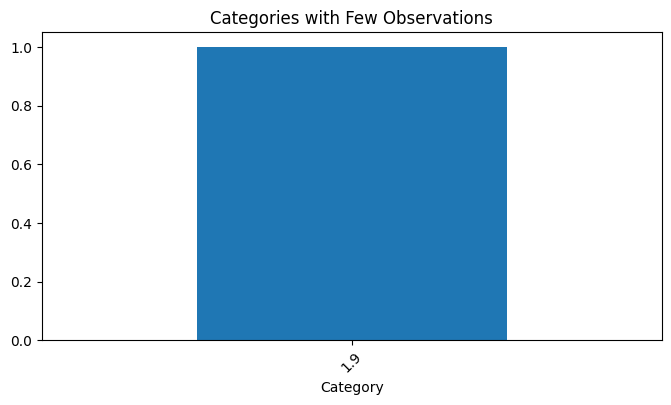

In [20]:
category_count = data['Category'].value_counts()

few_categories = category_count[category_count < 10]

print(few_categories)

few_categories.plot(kind='bar', figsize=(8,4), title='Categories with Few Observations')
plt.xticks(rotation=45)
plt.show()

Convert Reviews, Installs, Size, and Price into numeric form.

In [21]:
import numpy as np

# Reviews
data['Reviews'] = pd.to_numeric(data['Reviews'], errors='coerce')

# Installs
data['Installs'] = data['Installs'].str.replace('+','', regex=False)
data['Installs'] = data['Installs'].str.replace(',','', regex=False)
data['Installs'] = pd.to_numeric(data['Installs'], errors='coerce')

# Price
data['Price'] = data['Price'].str.replace('$','', regex=False)
data['Price'] = pd.to_numeric(data['Price'], errors='coerce')

# Size
def convert_size(x):
    if pd.isna(x):
        return np.nan
    x = str(x)
    if x.endswith('M'):
        return float(x[:-1])
    elif x.endswith('k'):
        return float(x[:-1]) / 1024
    else:
        return np.nan

data['Size'] = data['Size'].apply(convert_size)

data[['Reviews','Installs','Price','Size']].head()

,Reviews,Installs,Price,Size
0,159.0,10000.0,0.0,19.0
1,967.0,500000.0,0.0,14.0
2,87510.0,5000000.0,0.0,8.7
3,215644.0,50000000.0,0.0,25.0
4,967.0,100000.0,0.0,2.8


How many apps have zero reviews?

In [22]:
zero_reviews = data[data['Reviews'] == 0]

print("Apps with zero reviews:", zero_reviews.shape[0])

zero_reviews

Apps with zero reviews: 596


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
478,Truth or Dare Pro,DATING,NaN,0.0,20.000000,50.0,Paid,1.49,Teen,Dating,"September 1, 2017",1.0,4.0 and up
479,"Private Dating, Hide App- Blue for PrivacyHider",DATING,NaN,0.0,0.017578,100.0,Paid,2.99,Everyone,Dating,"July 25, 2017",1.0.1,4.0 and up
621,Dating White Girls,DATING,NaN,0.0,3.600000,50.0,Free,0.00,Mature 17+,Dating,"July 20, 2018",1.0,4.0 and up
623,Geeks Dating,DATING,NaN,0.0,13.000000,50.0,Free,0.00,Mature 17+,Dating,"July 10, 2018",1.0,4.1 and up
627,CAM5678 Video Chat,DATING,NaN,0.0,39.000000,500.0,Free,0.00,Mature 17+,Dating,"July 13, 2018",5.5.8,4.0.3 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10773,FQ India,LIFESTYLE,NaN,0.0,8.900000,10.0,Free,0.00,Everyone,Lifestyle,"July 31, 2018",7.2.2,4.1 and up
10774,Miss FQ,NEWS_AND_MAGAZINES,NaN,0.0,36.000000,10.0,Free,0.00,Everyone,News & Magazines,"April 5, 2018",3.8,4.4 and up
10798,Word Search Tab 1 FR,FAMILY,NaN,0.0,0.996094,50.0,Paid,1.04,Everyone,Puzzle,"February 6, 2012",1.1,3.0 and up
10822,PLMGSS FR,PRODUCTIVITY,NaN,0.0,3.100000,10.0,Free,0.00,Everyone,Productivity,"December 1, 2017",1,4.4 and up


How are ratings distributed? and Explain within markdown what u understood from this distribution

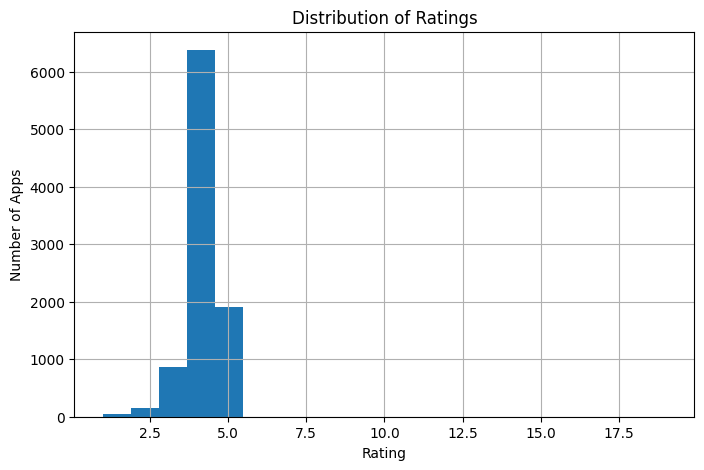

In [23]:
plt.figure(figsize=(8,5))

data['Rating'].dropna().hist(bins=20)

plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Apps')

plt.show()

Write Explaination Here
.
.
.
.
.

Are ratings normally distributed?

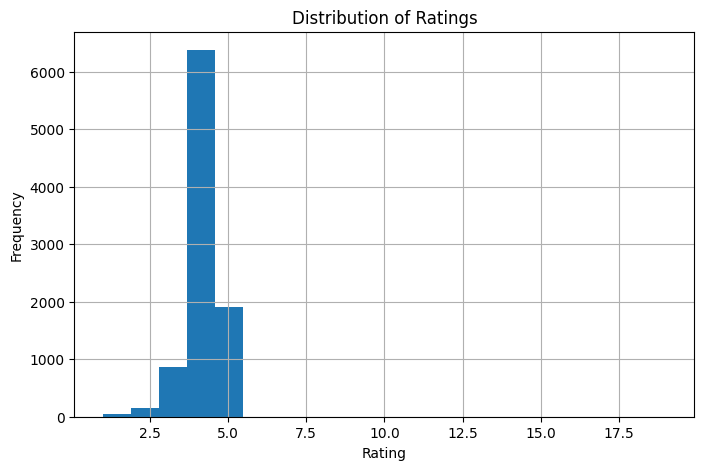

In [24]:
plt.figure(figsize=(8,5))

data['Rating'].dropna().hist(bins=20)

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

Explain.....

### Explanation

The ratings are **not normally distributed**.

- Most ratings are concentrated between **4.0 and 4.5**.
- There are very few apps with ratings below **3.0**.
- The histogram is negatively (left) skewed rather than bell-shaped.
- Therefore, the rating distribution does not follow a normal distribution.

Which rating range contains most apps?

Rating
0-1      16
1-2      52
2-3     302
3-4    2196
4-5    6800
Name: count, dtype: int64


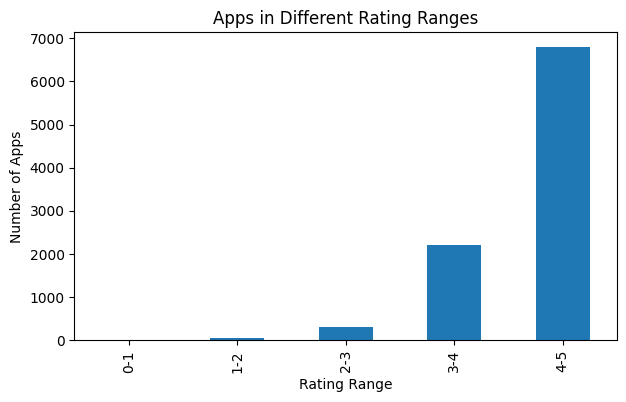

In [26]:
rating_range = pd.cut(
    data['Rating'],
    bins=[0,1,2,3,4,5],
    labels=['0-1','1-2','2-3','3-4','4-5']
)

rating_counts = rating_range.value_counts().sort_index()

print(rating_counts)

rating_counts.plot(kind='bar', figsize=(7,4))
plt.xlabel("Rating Range")
plt.ylabel("Number of Apps")
plt.title("Apps in Different Rating Ranges")
plt.show()

What is the average app size?

In [27]:
average_size = data['Size'].mean()

print("Average App Size:", round(average_size,2), "MB")

Average App Size: 21.52 MB


How are app sizes distributed?

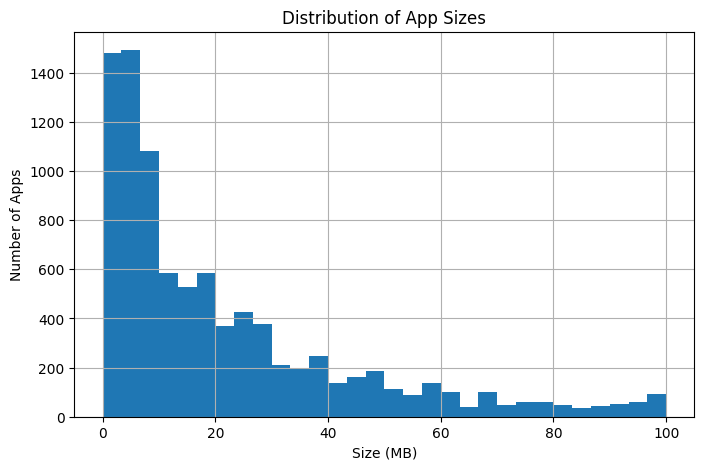

In [28]:
plt.figure(figsize=(8,5))

data['Size'].dropna().hist(bins=30)

plt.title("Distribution of App Sizes")
plt.xlabel("Size (MB)")
plt.ylabel("Number of Apps")

plt.show()

In [ ]:
Explain....

### Explanation

- Most applications are small to medium in size.
- Very large apps are comparatively fewer.
- The distribution is right-skewed because a few apps have much larger sizes than the majority.
- Most app sizes are below 40 MB.

Which content rating category is most common?

Content Rating
Everyone           8714
Teen               1208
Mature 17+          499
Everyone 10+        414
Adults only 18+       3
Unrated               2
Name: count, dtype: int64

Most Common Content Rating: Everyone


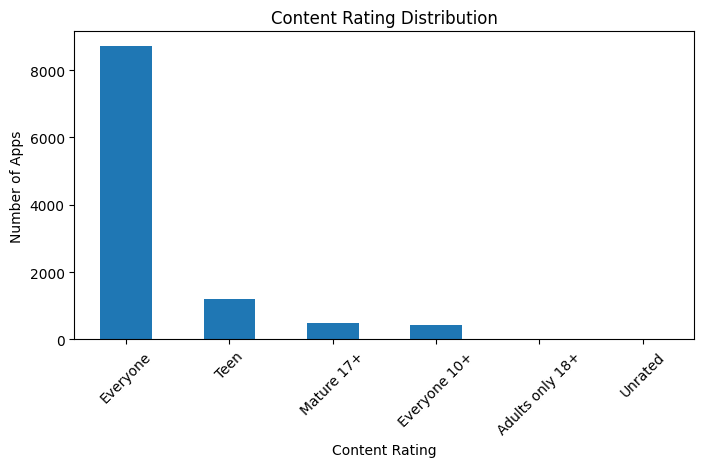

In [29]:
content_rating = data['Content Rating'].value_counts()

print(content_rating)

print("\nMost Common Content Rating:", content_rating.idxmax())

content_rating.plot(kind='bar', figsize=(8,4))
plt.title("Content Rating Distribution")
plt.xlabel("Content Rating")
plt.ylabel("Number of Apps")
plt.xticks(rotation=45)
plt.show()

What percentage of apps are free?

In [30]:
free_percentage = (data['Type'] == 'Free').mean() * 100

print(f"Percentage of Free Apps: {free_percentage:.2f}%")

Percentage of Free Apps: 92.60%


What percentage are paid?

In [31]:
paid_percentage = (data['Type'] == 'Paid').mean() * 100

print(f"Percentage of Paid Apps: {paid_percentage:.2f}%")

Percentage of Paid Apps: 7.38%


What is the maximum price of an app?

In [32]:
max_price = data['Price'].max()

print("Maximum App Price: $", max_price)

Maximum App Price: $ 400.0


Which category contains the largest number of apps?

In [33]:
category_count = data['Category'].value_counts()

print("Category with the largest number of apps:")
print(category_count.head(1))

Category with the largest number of apps:
Category
FAMILY    1972
Name: count, dtype: int64


Which category contains the fewest apps?

In [34]:
category_count = data['Category'].value_counts()

print("Category with the fewest number of apps:")
print(category_count.tail(1))

Category with the fewest number of apps:
Category
1.9    1
Name: count, dtype: int64


Which category has the highest average rating?

In [35]:
avg_rating = data.groupby('Category')['Rating'].mean().sort_values(ascending=False)

print(avg_rating.head())

print("\nCategory with Highest Average Rating:")
print(avg_rating.idxmax(), ":", round(avg_rating.max(), 2))

Category
1.9                    19.000000
EVENTS                  4.435556
EDUCATION               4.389032
ART_AND_DESIGN          4.358065
BOOKS_AND_REFERENCE     4.346067
Name: Rating, dtype: float64

Category with Highest Average Rating:
1.9 : 19.0


Which category has the lowest average rating?

In [36]:
avg_rating = data.groupby("Category")["Rating"].mean().sort_values()

print("Category with Lowest Average Rating:")
print(avg_rating.head(1))

Category with Lowest Average Rating:
Category
DATING    3.970769
Name: Rating, dtype: float64


Which category receives the highest total number of reviews?

In [37]:
total_reviews = data.groupby("Category")["Reviews"].sum().sort_values(ascending=False)

print("Category with Highest Total Reviews:")
print(total_reviews.head(1))

Category with Highest Total Reviews:
Category
GAME    1.585422e+09
Name: Reviews, dtype: float64


Which category has the highest average installs?

In [38]:
avg_installs = data.groupby("Category")["Installs"].mean().sort_values(ascending=False)

print("Category with Highest Average Installs:")
print(avg_installs.head(1))

Category with Highest Average Installs:
Category
COMMUNICATION    8.435989e+07
Name: Installs, dtype: float64


Which category has the largest app sizes?

In [39]:
avg_size = data.groupby("Category")["Size"].mean().sort_values(ascending=False)

print("Category with Largest Average App Size:")
print(avg_size.head(1))

Category with Largest Average App Size:
Category
GAME    44.370065
Name: Size, dtype: float64


Which category contains the most paid apps?

In [40]:
paid_apps = data[data["Type"]=="Paid"]

paid_count = paid_apps["Category"].value_counts()

print("Category with Most Paid Apps:")
print(paid_count.head(1))

Category with Most Paid Apps:
Category
FAMILY    191
Name: count, dtype: int64


Which category contains the highest percentage of free apps?

In [41]:
free_percentage = (
    data.groupby("Category")["Type"]
        .apply(lambda x: (x=="Free").mean()*100)
        .sort_values(ascending=False)
)

print("Category with Highest Percentage of Free Apps:")
print(free_percentage.head(1))

Category with Highest Percentage of Free Apps:
Category
COMICS    100.0
Name: Type, dtype: float64


Are certain categories dominated by a single content rating?

In [42]:
content_category = pd.crosstab(
    data["Category"],
    data["Content Rating"],
    normalize="index"
) * 100

content_category.round(2)

Content Rating,Adults only 18+,Everyone,Everyone 10+,Mature 17+,Teen,Unrated
Category,,,,,,
ART_AND_DESIGN,0.00,93.85,1.54,0.00,4.62,0.00
AUTO_AND_VEHICLES,0.00,97.65,1.18,0.00,1.18,0.00
BEAUTY,0.00,84.91,3.77,5.66,5.66,0.00
BOOKS_AND_REFERENCE,0.00,87.45,2.16,1.30,9.09,0.00
BUSINESS,0.00,96.74,0.22,0.22,2.83,0.00
COMICS,3.33,43.33,5.00,11.67,36.67,0.00
COMMUNICATION,0.00,89.15,0.00,2.58,8.27,0.00
DATING,0.00,8.97,0.00,85.90,5.13,0.00
EDUCATION,0.00,92.31,5.13,1.92,0.64,0.00


What are the top 20 highest-rated apps?

In [43]:
top20_apps = data.sort_values(
    by=["Rating", "Reviews"],
    ascending=[False, False]
)[["App", "Category", "Rating", "Reviews"]].head(20)

top20_apps

,App,Category,Rating,Reviews
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,NaN
10357,Ríos de Fe,LIFESTYLE,5.0,141.0
10301,"FD Calculator (EMI, SIP, RD & Loan Eligilibility)",FINANCE,5.0,104.0
8058,Oración CX,LIFESTYLE,5.0,103.0
6823,Barisal University App-BU Face,FAMILY,5.0,100.0
9496,Master E.K,FAMILY,5.0,90.0
7506,CL REPL,TOOLS,5.0,47.0
5230,AJ Cam,PHOTOGRAPHY,5.0,44.0
5196,AI Today : Artificial Intelligence News & AI 101,NEWS_AND_MAGAZINES,5.0,43.0
7842,CS & IT Interview Questions,FAMILY,5.0,43.0


Which category contributes most of the 5-star apps?

In [44]:
five_star = data[data["Rating"] == 5.0]

five_star_category = five_star["Category"].value_counts()

print(five_star_category)

print("\nCategory contributing the most 5-star apps:")
print(five_star_category.idxmax())

Category
FAMILY                 67
LIFESTYLE              29
MEDICAL                28
BUSINESS               18
TOOLS                  17
HEALTH_AND_FITNESS     12
GAME                   12
PERSONALIZATION        10
FINANCE                 8
SOCIAL                  8
PRODUCTIVITY            8
NEWS_AND_MAGAZINES      7
PHOTOGRAPHY             6
DATING                  6
SHOPPING                6
EVENTS                  6
BOOKS_AND_REFERENCE     6
COMMUNICATION           5
SPORTS                  4
TRAVEL_AND_LOCAL        3
COMICS                  2
LIBRARIES_AND_DEMO      2
FOOD_AND_DRINK          2
PARENTING               1
ART_AND_DESIGN          1
Name: count, dtype: int64

Category contributing the most 5-star apps:
FAMILY


Do apps with more reviews receive higher ratings?

Correlation between Reviews and Rating: 0.068


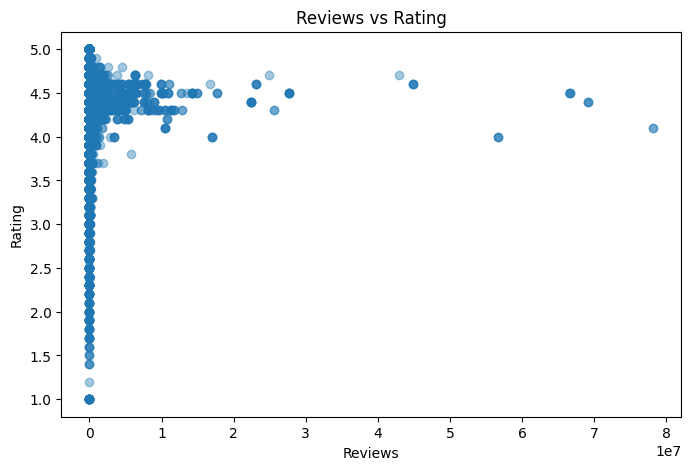

In [45]:
correlation = data["Reviews"].corr(data["Rating"])

print("Correlation between Reviews and Rating:", round(correlation,3))

plt.figure(figsize=(8,5))
plt.scatter(data["Reviews"], data["Rating"], alpha=0.4)
plt.xlabel("Reviews")
plt.ylabel("Rating")
plt.title("Reviews vs Rating")
plt.show()

Do highly installed apps have better ratings?

Correlation between Installs and Rating: 0.051


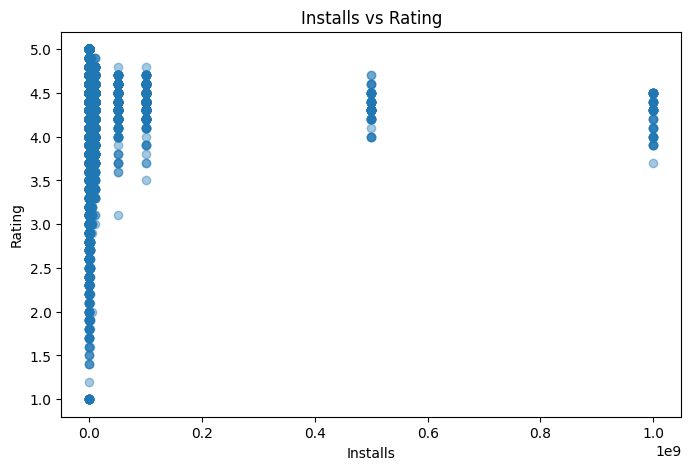

In [46]:
correlation = data["Installs"].corr(data["Rating"])

print("Correlation between Installs and Rating:", round(correlation,3))

plt.figure(figsize=(8,5))
plt.scatter(data["Installs"], data["Rating"], alpha=0.4)
plt.xlabel("Installs")
plt.ylabel("Rating")
plt.title("Installs vs Rating")
plt.show()

Which category has the greatest variation in ratings?

In [47]:
rating_std = data.groupby("Category")["Rating"].std().sort_values(ascending=False)

print("Category with Greatest Rating Variation:")
print(rating_std.head(1))

Category with Greatest Rating Variation:
Category
LIFESTYLE    0.693907
Name: Rating, dtype: float64


Are ratings different between free and paid apps?

Type
0       19.000000
Free     4.186203
Paid     4.266615
Name: Rating, dtype: float64


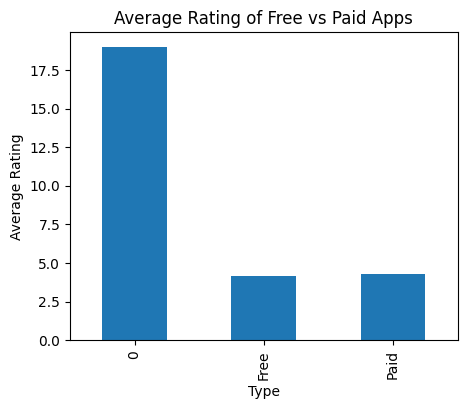

In [48]:
avg_rating_type = data.groupby("Type")["Rating"].mean()

print(avg_rating_type)

avg_rating_type.plot(kind="bar", figsize=(5,4))
plt.title("Average Rating of Free vs Paid Apps")
plt.ylabel("Average Rating")
plt.show()

Which apps have the highest installs?

In [49]:
highest_installs = data.sort_values(
    by="Installs",
    ascending=False
)[["App", "Category", "Installs"]].drop_duplicates(subset="App")

highest_installs.head(20)

,App,Category,Installs
2808,Google Photos,PHOTOGRAPHY,1.000000e+09
3223,Maps - Navigate & Explore,TRAVEL_AND_LOCAL,1.000000e+09
3234,Google,TOOLS,1.000000e+09
3232,Google Street View,TRAVEL_AND_LOCAL,1.000000e+09
2554,Google+,SOCIAL,1.000000e+09
464,Hangouts,COMMUNICATION,1.000000e+09
468,Skype - free IM & video calls,COMMUNICATION,1.000000e+09
451,Gmail,COMMUNICATION,1.000000e+09
3454,Google Drive,PRODUCTIVITY,1.000000e+09
2611,Instagram,SOCIAL,1.000000e+09


Do larger apps tend to have higher ratings?

Correlation between Size and Rating: 0.084


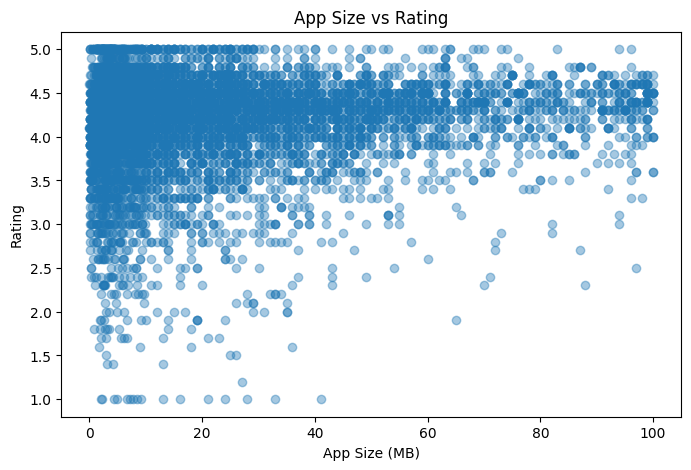

In [50]:
correlation = data["Size"].corr(data["Rating"])

print("Correlation between Size and Rating:", round(correlation,3))

plt.figure(figsize=(8,5))
plt.scatter(data["Size"], data["Rating"], alpha=0.4)
plt.xlabel("App Size (MB)")
plt.ylabel("Rating")
plt.title("App Size vs Rating")
plt.show()

Are older apps rated differently than recently updated apps?

Year
2010.0    4.200000
2011.0    3.966667
2012.0    3.785714
2013.0    4.073404
2014.0    4.037895
2015.0    4.067268
2016.0    4.041782
2017.0    4.094793
2018.0    4.244530
Name: Rating, dtype: float64


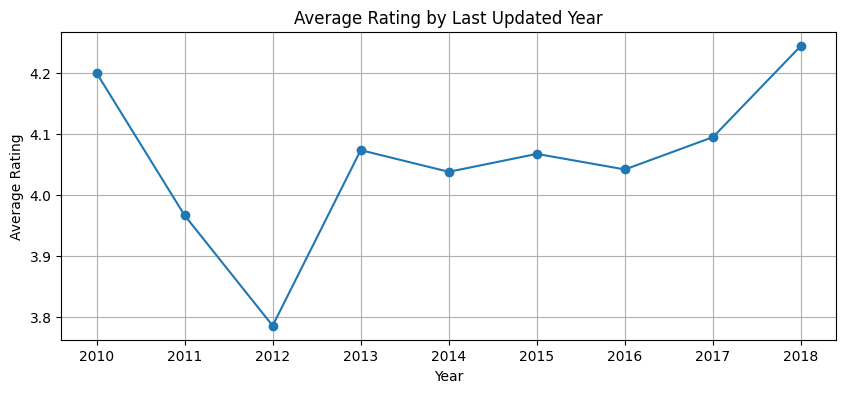

In [51]:
data["Last Updated"] = pd.to_datetime(data["Last Updated"], errors="coerce")

data["Year"] = data["Last Updated"].dt.year

year_rating = data.groupby("Year")["Rating"].mean()

print(year_rating)

year_rating.plot(figsize=(10,4), marker="o")
plt.title("Average Rating by Last Updated Year")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.grid(True)
plt.show()

Which category has the most consistent ratings?

In [52]:
rating_std = data.groupby("Category")["Rating"].std().sort_values()

print("Most Consistent Category:")
print(rating_std.head(1))

Most Consistent Category:
Category
EDUCATION    0.251894
Name: Rating, dtype: float64


Which category contributes the highest total installs?

In [53]:
total_installs = data.groupby("Category")["Installs"].sum().sort_values(ascending=False)

print("Highest Total Installs:")
print(total_installs.head(1))

Highest Total Installs:
Category
GAME    3.508602e+10
Name: Installs, dtype: float64


What is the relationship between reviews and ratings?

Correlation: 0.068


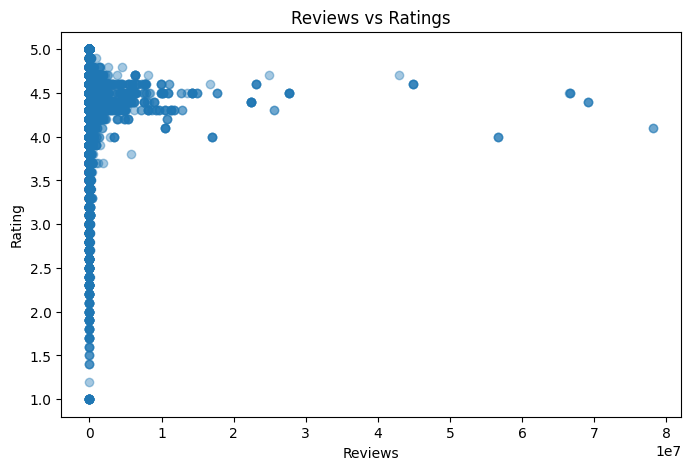

In [54]:
correlation = data["Reviews"].corr(data["Rating"])

print("Correlation:", round(correlation,3))

plt.figure(figsize=(8,5))
plt.scatter(data["Reviews"], data["Rating"], alpha=0.4)
plt.xlabel("Reviews")
plt.ylabel("Rating")
plt.title("Reviews vs Ratings")
plt.show()

Do paid apps receive fewer installs than free apps?

Type
0                NaN
Free    1.669095e+07
Paid    9.119510e+04
Name: Installs, dtype: float64


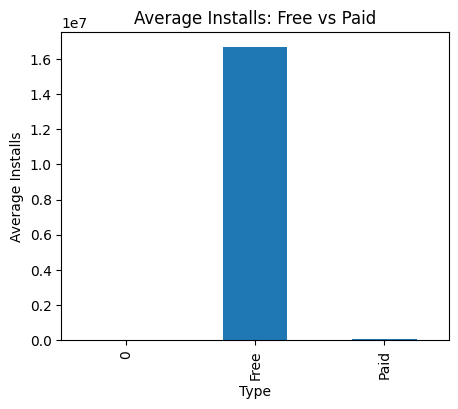

In [55]:
avg_installs = data.groupby("Type")["Installs"].mean()

print(avg_installs)

avg_installs.plot(kind="bar", figsize=(5,4))
plt.title("Average Installs: Free vs Paid")
plt.ylabel("Average Installs")
plt.show()

What percentage of apps have fewer than 10,000 installs?

In [56]:
less_10k = (data["Installs"] < 10000).mean() * 100

print(f"Percentage of apps with fewer than 10,000 installs: {less_10k:.2f}%")

Percentage of apps with fewer than 10,000 installs: 29.41%


Are highly-rated apps downloaded more frequently?

Correlation between Rating and Installs: 0.051


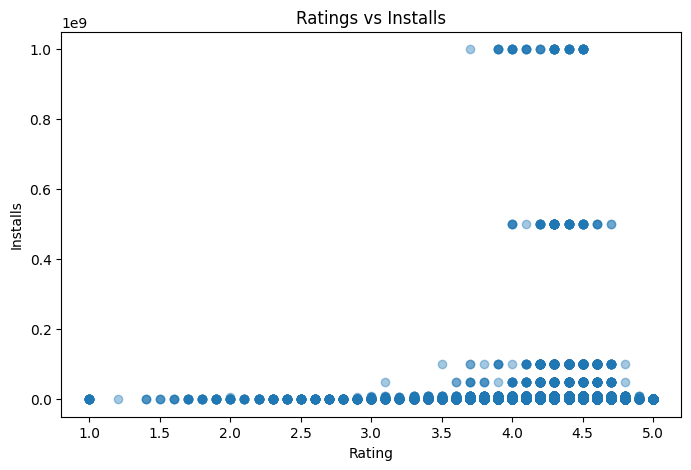

In [57]:
correlation = data["Rating"].corr(data["Installs"])

print("Correlation between Rating and Installs:", round(correlation,3))

plt.figure(figsize=(8,5))
plt.scatter(data["Rating"], data["Installs"], alpha=0.4)
plt.xlabel("Rating")
plt.ylabel("Installs")
plt.title("Ratings vs Installs")
plt.show()

Which content-rating group has the highest installs?

In [58]:
content_installs = data.groupby("Content Rating")["Installs"].sum().sort_values(ascending=False)

print(content_installs)

print("\nHighest Install Content Rating:")
print(content_installs.head(1))

Content Rating
Everyone           1.141567e+11
Teen               3.471635e+10
Everyone 10+       1.323388e+10
Mature 17+         5.524491e+09
Adults only 18+    2.000000e+06
Unrated            5.050000e+04
Name: Installs, dtype: float64

Highest Install Content Rating:
Content Rating
Everyone    1.141567e+11
Name: Installs, dtype: float64


Which category contains the greatest number of apps with over 1 million installs?

In [59]:
million_apps = data[data["Installs"] >= 1000000]

million_category = million_apps["Category"].value_counts()

print(million_category)

print("\nCategory with Most Apps over 1 Million Installs:")
print(million_category.head(1))

Category
GAME                   737
FAMILY                 651
TOOLS                  289
PHOTOGRAPHY            226
COMMUNICATION          212
PRODUCTIVITY           197
SPORTS                 174
SHOPPING               161
SOCIAL                 156
HEALTH_AND_FITNESS     156
ENTERTAINMENT          132
TRAVEL_AND_LOCAL       132
PERSONALIZATION        126
NEWS_AND_MAGAZINES     112
FINANCE                111
EDUCATION              108
BUSINESS                97
VIDEO_PLAYERS           95
LIFESTYLE               89
FOOD_AND_DRINK          63
BOOKS_AND_REFERENCE     61
MAPS_AND_NAVIGATION     60
DATING                  58
WEATHER                 45
HOUSE_AND_HOME          43
MEDICAL                 26
AUTO_AND_VEHICLES       18
COMICS                  18
PARENTING               15
LIBRARIES_AND_DEMO      14
ART_AND_DESIGN          13
BEAUTY                  10
EVENTS                   6
Name: count, dtype: int64

Category with Most Apps over 1 Million Installs:
Category
GAME    737
Nam

Are installs concentrated among a few apps?

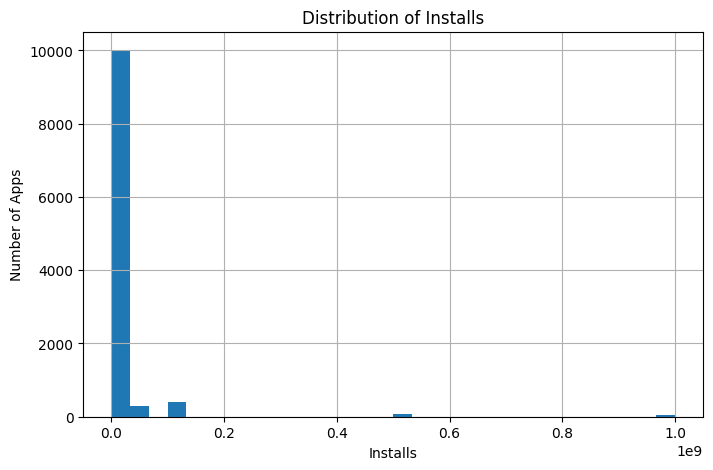

In [60]:
plt.figure(figsize=(8,5))

data["Installs"].hist(bins=30)

plt.title("Distribution of Installs")
plt.xlabel("Installs")
plt.ylabel("Number of Apps")

plt.show()

What is the average price of paid apps?

In [61]:
paid_apps = data[data["Type"] == "Paid"]

average_price = paid_apps["Price"].mean()

print(f"Average Price of Paid Apps: ${average_price:.2f}")

Average Price of Paid Apps: $13.92


Which category has the most expensive apps?

In [62]:
max_price_category = data.groupby("Category")["Price"].max().sort_values(ascending=False)

print(max_price_category)

print("\nCategory with Most Expensive Apps:")
print(max_price_category.head(1))

Category
LIFESTYLE              400.00
FINANCE                399.99
FAMILY                 399.99
MEDICAL                200.00
PRODUCTIVITY           154.99
EVENTS                 109.99
BUSINESS                89.99
SPORTS                  29.99
PHOTOGRAPHY             29.99
TOOLS                   25.99
COMMUNICATION           19.99
GAME                    17.99
SOCIAL                  13.99
MAPS_AND_NAVIGATION     11.99
PERSONALIZATION          9.99
AUTO_AND_VEHICLES        9.99
HEALTH_AND_FITNESS       9.99
TRAVEL_AND_LOCAL         8.99
DATING                   7.99
WEATHER                  6.99
BOOKS_AND_REFERENCE      6.49
VIDEO_PLAYERS            5.99
EDUCATION                5.99
PARENTING                4.99
ENTERTAINMENT            4.99
FOOD_AND_DRINK           4.99
SHOPPING                 2.99
NEWS_AND_MAGAZINES       2.99
ART_AND_DESIGN           1.99
LIBRARIES_AND_DEMO       0.99
HOUSE_AND_HOME           0.00
BEAUTY                   0.00
COMICS                   0.00
1

What is the distribution of installs?

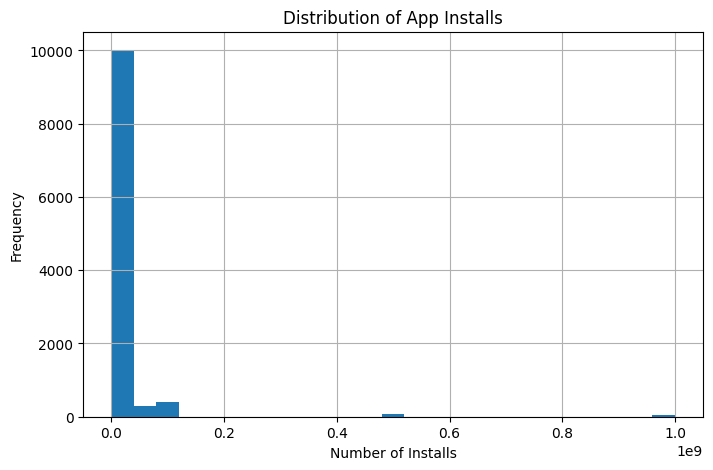

In [63]:
plt.figure(figsize=(8,5))

data["Installs"].dropna().hist(bins=25)

plt.title("Distribution of App Installs")
plt.xlabel("Number of Installs")
plt.ylabel("Frequency")

plt.show()

Which genre contains the largest number of apps?

Genre with the Largest Number of Apps:
Genres
Tools    842
Name: count, dtype: int64


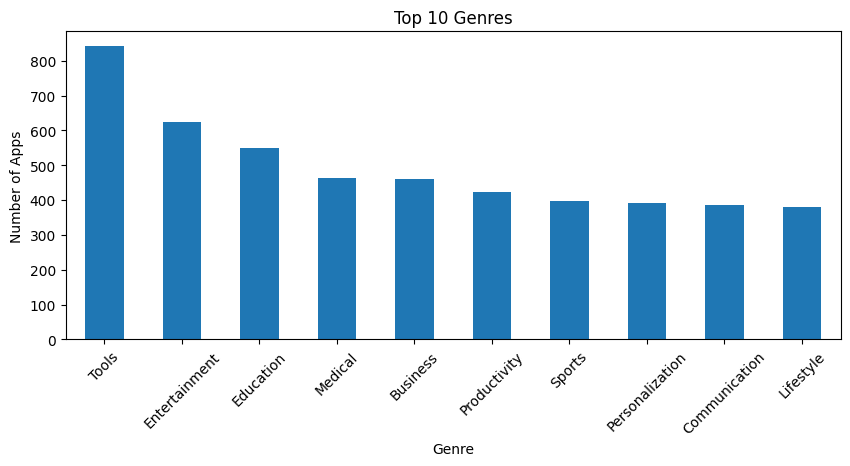

In [64]:
genre_count = data["Genres"].value_counts()

print("Genre with the Largest Number of Apps:")
print(genre_count.head(1))

genre_count.head(10).plot(kind="bar", figsize=(10,4))
plt.title("Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Apps")
plt.xticks(rotation=45)
plt.show()

Does higher price imply higher ratings?

Correlation between Price and Rating: -0.022


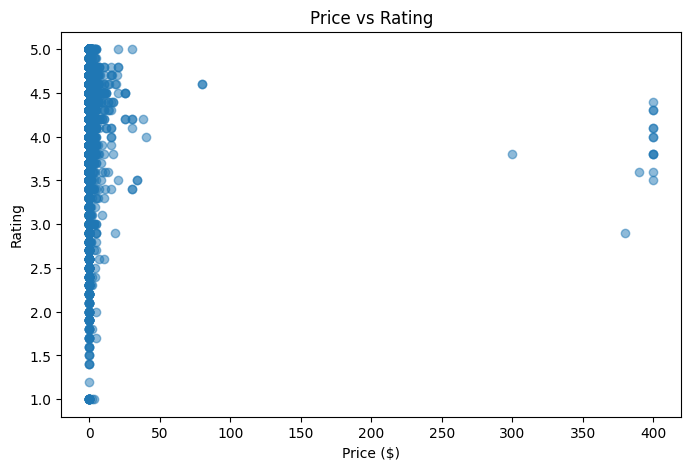

In [65]:
correlation = data["Price"].corr(data["Rating"])

print("Correlation between Price and Rating:", round(correlation,3))

plt.figure(figsize=(8,5))
plt.scatter(data["Price"], data["Rating"], alpha=0.5)
plt.xlabel("Price ($)")
plt.ylabel("Rating")
plt.title("Price vs Rating")
plt.show()

Which app is the most expensive?

In [66]:
most_expensive = data.sort_values("Price", ascending=False)

most_expensive[["App","Category","Price"]].head(1)

,App,Category,Price
4367,I'm Rich - Trump Edition,LIFESTYLE,400.0


Which category generates the highest total revenue potential?

Category
FAMILY         1.860526e+08
LIFESTYLE      5.758394e+07
GAME           4.098764e+07
FINANCE        2.572668e+07
PHOTOGRAPHY    2.092277e+07
Name: Revenue_Potential, dtype: float64


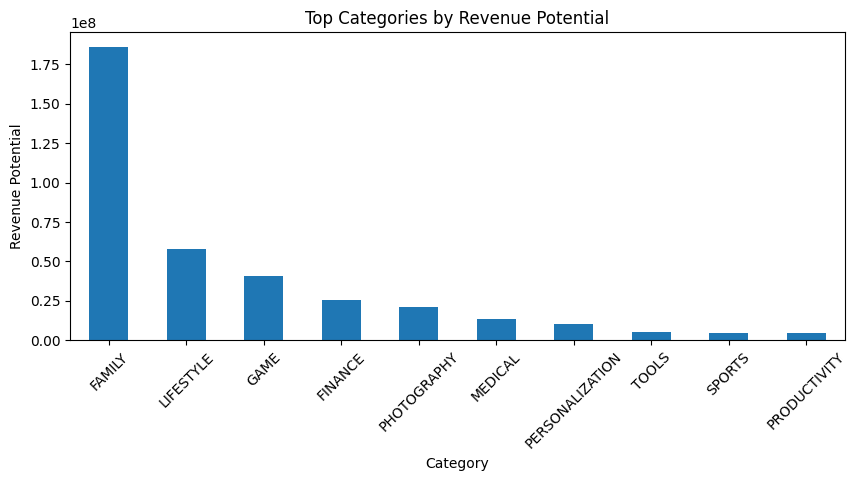

In [67]:
data["Revenue_Potential"] = data["Price"] * data["Installs"]

revenue = data.groupby("Category")["Revenue_Potential"].sum().sort_values(ascending=False)

print(revenue.head())

revenue.head(10).plot(kind="bar", figsize=(10,4))
plt.title("Top Categories by Revenue Potential")
plt.xlabel("Category")
plt.ylabel("Revenue Potential")
plt.xticks(rotation=45)
plt.show()

Does price affect installs?

Correlation: -0.012


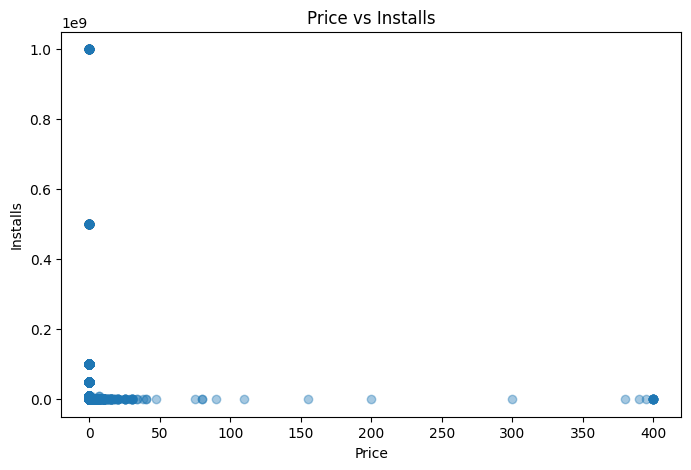

In [68]:
correlation = data["Price"].corr(data["Installs"])

print("Correlation:", round(correlation,3))

plt.figure(figsize=(8,5))
plt.scatter(data["Price"], data["Installs"], alpha=0.4)
plt.xlabel("Price")
plt.ylabel("Installs")
plt.title("Price vs Installs")
plt.show()

Do paid apps receive more reviews than free apps?

Type
0                 NaN
Free    478661.096026
Paid     11673.312500
Name: Reviews, dtype: float64


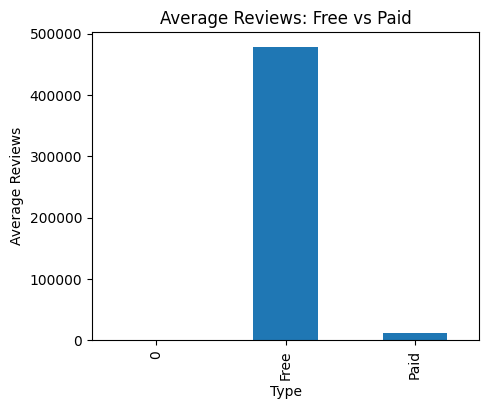

In [69]:
review_type = data.groupby("Type")["Reviews"].mean()

print(review_type)

review_type.plot(kind="bar", figsize=(5,4))
plt.title("Average Reviews: Free vs Paid")
plt.ylabel("Average Reviews")
plt.show()

What percentage of apps cost more than $10? and Figure out some other pricing ranges?

In [70]:
total_apps = len(data)

more_than_10 = (data["Price"] > 10).sum()

percentage = (more_than_10 / total_apps) * 100

print(f"Apps costing more than $10: {percentage:.2f}%")

Apps costing more than $10: 0.82%


Is there a relationship between app size and price?

Correlation between Size and Price: -0.023


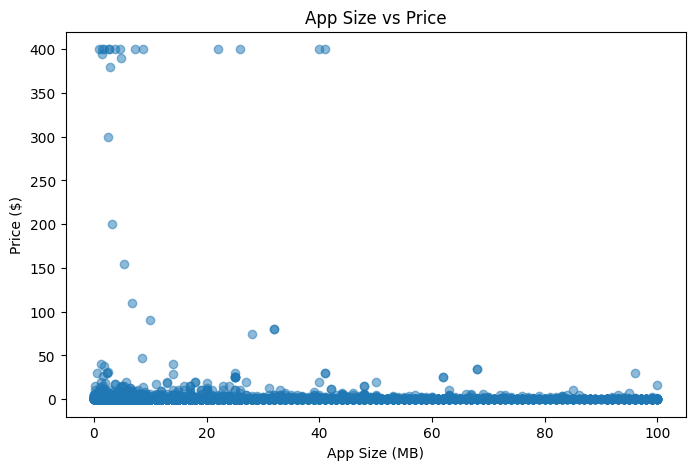

In [71]:
correlation = data["Size"].corr(data["Price"])

print("Correlation between Size and Price:", round(correlation,3))

plt.figure(figsize=(8,5))
plt.scatter(data["Size"], data["Price"], alpha=0.5)
plt.xlabel("App Size (MB)")
plt.ylabel("Price ($)")
plt.title("App Size vs Price")
plt.show()

In which year were the most apps updated?

Year
2010.0       1
2011.0      15
2012.0      26
2013.0     110
2014.0     209
2015.0     459
2016.0     804
2017.0    1867
2018.0    7349
Name: count, dtype: int64

Year with Most Updated Apps:
2018.0


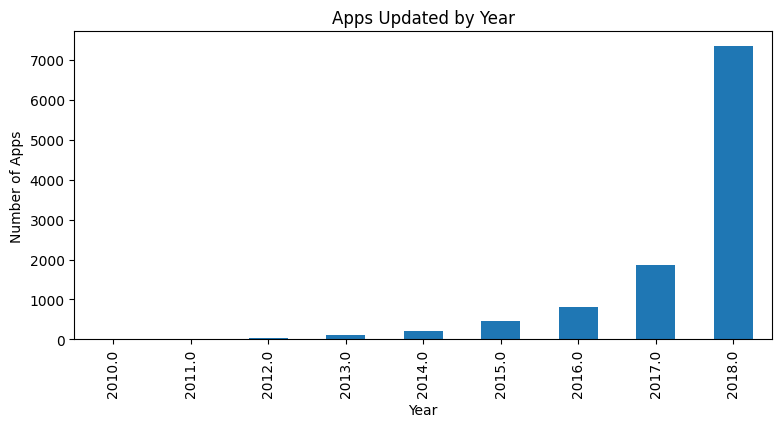

In [72]:
data["Last Updated"] = pd.to_datetime(data["Last Updated"], errors="coerce")

data["Year"] = data["Last Updated"].dt.year

year_count = data["Year"].value_counts().sort_index()

print(year_count)

print("\nYear with Most Updated Apps:")
print(year_count.idxmax())

year_count.plot(kind="bar", figsize=(9,4))
plt.title("Apps Updated by Year")
plt.xlabel("Year")
plt.ylabel("Number of Apps")
plt.show()

Have app ratings improved over the years?

Year
2010.0    4.200000
2011.0    3.966667
2012.0    3.785714
2013.0    4.073404
2014.0    4.037895
2015.0    4.067268
2016.0    4.041782
2017.0    4.094793
2018.0    4.244530
Name: Rating, dtype: float64


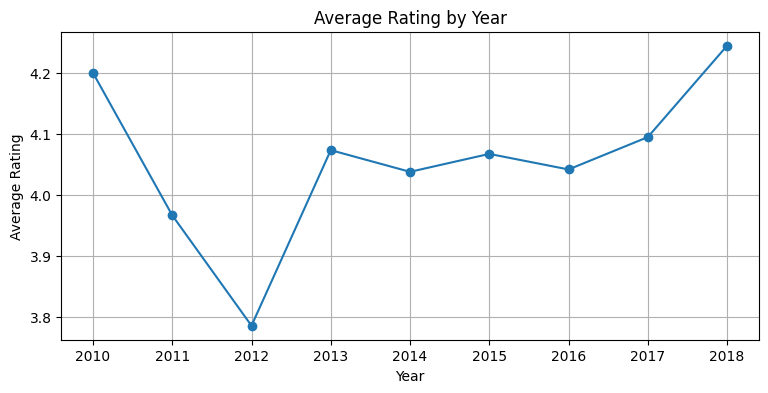

In [73]:
rating_year = data.groupby("Year")["Rating"].mean()

print(rating_year)

rating_year.plot(marker="o", figsize=(9,4))
plt.title("Average Rating by Year")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.grid(True)
plt.show()

What proportion of apps have not been updated in the last two years?

In [74]:
latest_year = data["Year"].max()

old_apps = (data["Year"] < latest_year - 2).sum()

percentage = old_apps / len(data) * 100

print(f"Apps not updated in the last two years: {percentage:.2f}%")

Apps not updated in the last two years: 7.56%


Which content rating has the highest average rating?

In [75]:
content_rating = data.groupby("Content Rating")["Rating"].mean().sort_values(ascending=False)

print(content_rating)

print("\nHighest Average Rating:")
print(content_rating.head(1))

Content Rating
Adults only 18+    4.300000
Everyone 10+       4.257179
Teen               4.233487
Everyone           4.186375
Mature 17+         4.123427
Unrated            4.100000
Name: Rating, dtype: float64

Highest Average Rating:
Content Rating
Adults only 18+    4.3
Name: Rating, dtype: float64


Which categories have many outdated apps?

Category
FAMILY                 172
GAME                   112
TOOLS                   94
PERSONALIZATION         57
MEDICAL                 43
PRODUCTIVITY            38
BUSINESS                37
BOOKS_AND_REFERENCE     36
COMMUNICATION           34
LIFESTYLE               29
Name: count, dtype: int64


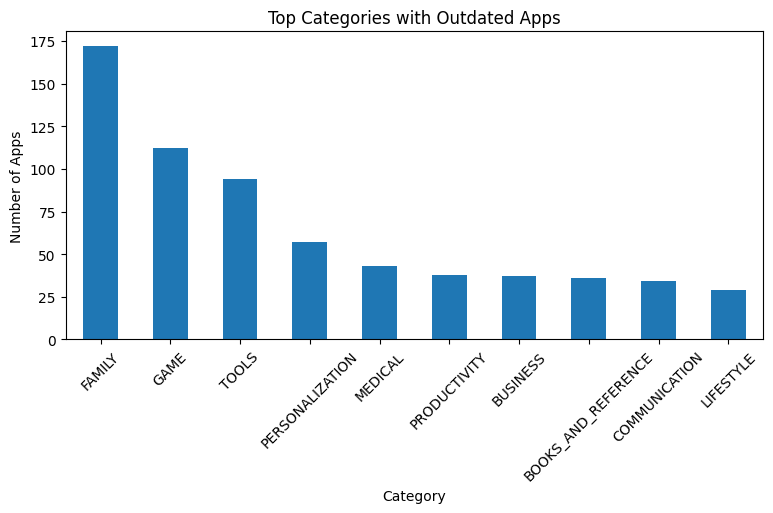

In [76]:
outdated = data[data["Year"] < latest_year - 2]

outdated_category = outdated["Category"].value_counts()

print(outdated_category.head(10))

outdated_category.head(10).plot(kind="bar", figsize=(9,4))
plt.title("Top Categories with Outdated Apps")
plt.xlabel("Category")
plt.ylabel("Number of Apps")
plt.xticks(rotation=45)
plt.show()

Which content rating gets the most reviews?

In [77]:
review_content = data.groupby("Content Rating")["Reviews"].sum().sort_values(ascending=False)

print(review_content)

print("\nContent Rating with Most Reviews:")
print(review_content.head(1))

Content Rating
Everyone           2.801847e+09
Teen               1.131524e+09
Everyone 10+       6.839972e+08
Mature 17+         1.971665e+08
Adults only 18+    8.134800e+04
Unrated            1.187000e+03
Name: Reviews, dtype: float64

Content Rating with Most Reviews:
Content Rating
Everyone    2.801847e+09
Name: Reviews, dtype: float64


Are Mature 17+ apps generally more expensive?

Content Rating
Everyone           1.171173
Teen               0.543278
Everyone 10+       0.378478
Mature 17+         0.236673
Adults only 18+    0.000000
Unrated            0.000000
Name: Price, dtype: float64


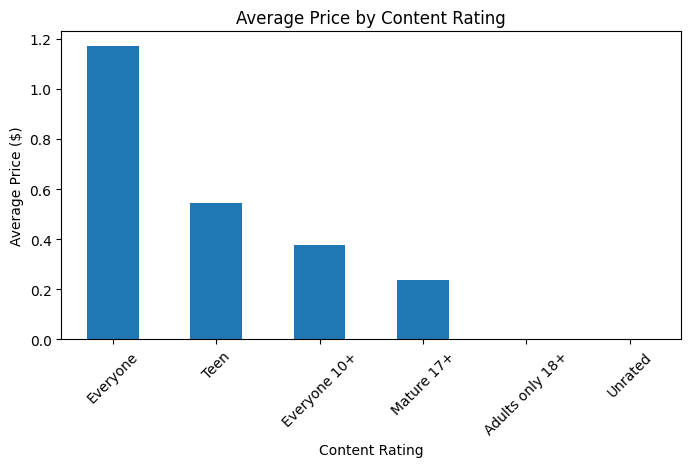

In [78]:
price_content = data.groupby("Content Rating")["Price"].mean().sort_values(ascending=False)

print(price_content)

price_content.plot(kind="bar", figsize=(8,4))
plt.title("Average Price by Content Rating")
plt.xlabel("Content Rating")
plt.ylabel("Average Price ($)")
plt.xticks(rotation=45)
plt.show()

Which genre contains the most expensive apps?

# Relationship Analysis
    Relationship between Reviews and Installs?



    Relationship between Price and Installs?



    Relationship between Size and Rating?



    Relationship between Reviews and Rating?



    Relationship between Size and Installs?



    Relationship between Price and Reviews?



    Relationship between App Size and Revenue Potential?

Correlation: 0.643


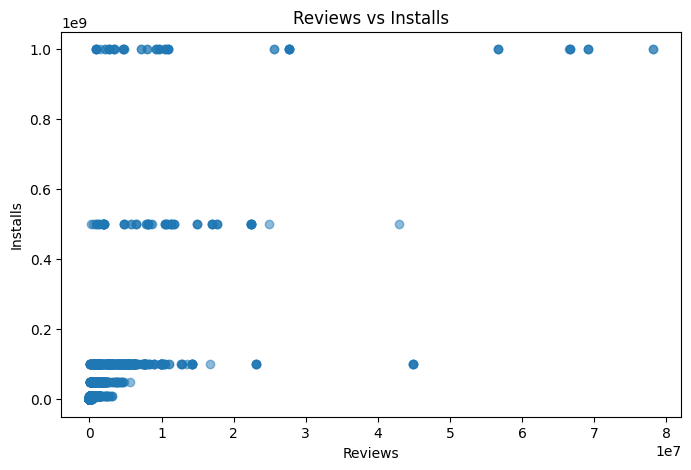

In [79]:
correlation = data["Reviews"].corr(data["Installs"])

print("Correlation:", round(correlation,3))

plt.figure(figsize=(8,5))
plt.scatter(data["Reviews"], data["Installs"], alpha=0.5)
plt.xlabel("Reviews")
plt.ylabel("Installs")
plt.title("Reviews vs Installs")
plt.show()

Correlation: -0.012


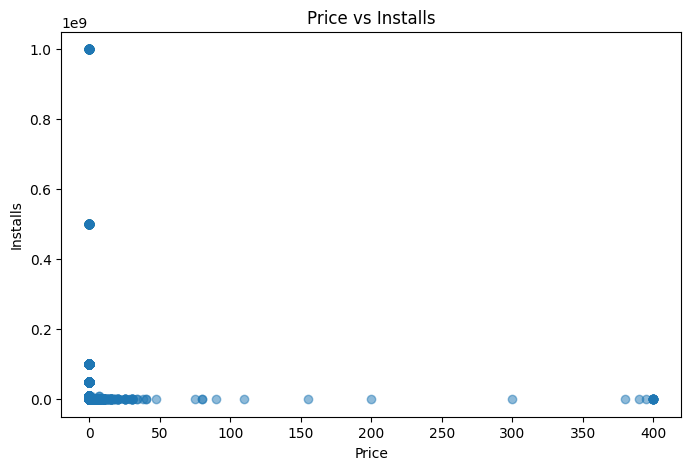

In [80]:
correlation = data["Price"].corr(data["Installs"])

print("Correlation:", round(correlation,3))

plt.figure(figsize=(8,5))
plt.scatter(data["Price"], data["Installs"], alpha=0.5)
plt.xlabel("Price")
plt.ylabel("Installs")
plt.title("Price vs Installs")
plt.show()

Correlation: 0.084


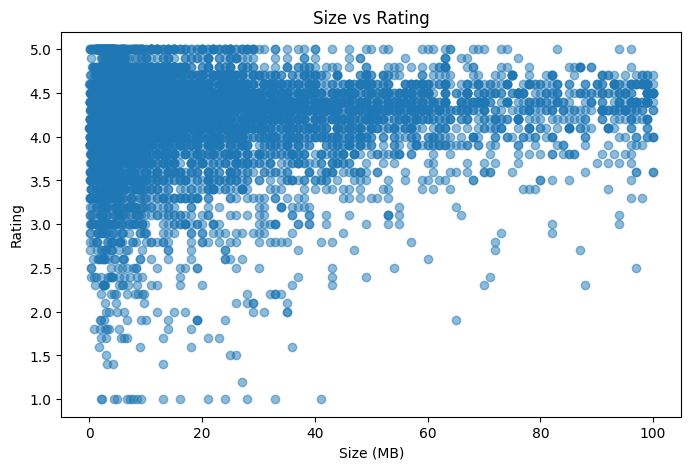

In [81]:
correlation = data["Size"].corr(data["Rating"])

print("Correlation:", round(correlation,3))

plt.figure(figsize=(8,5))
plt.scatter(data["Size"], data["Rating"], alpha=0.5)
plt.xlabel("Size (MB)")
plt.ylabel("Rating")
plt.title("Size vs Rating")
plt.show()

Correlation: 0.068


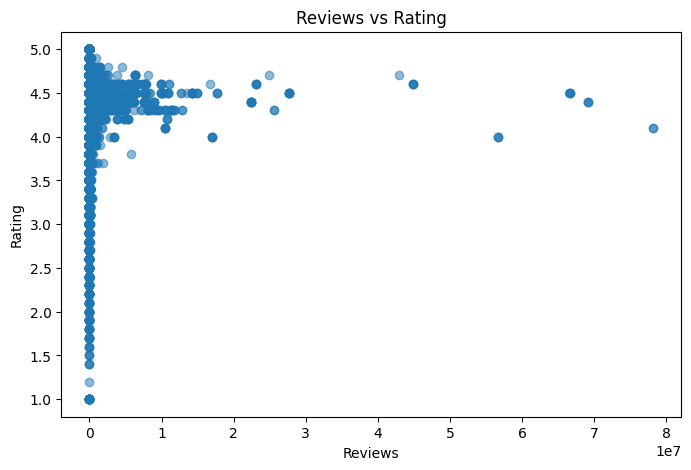

In [82]:
correlation = data["Reviews"].corr(data["Rating"])

print("Correlation:", round(correlation,3))

plt.figure(figsize=(8,5))
plt.scatter(data["Reviews"], data["Rating"], alpha=0.5)
plt.xlabel("Reviews")
plt.ylabel("Rating")
plt.title("Reviews vs Rating")
plt.show()

Correlation: 0.165


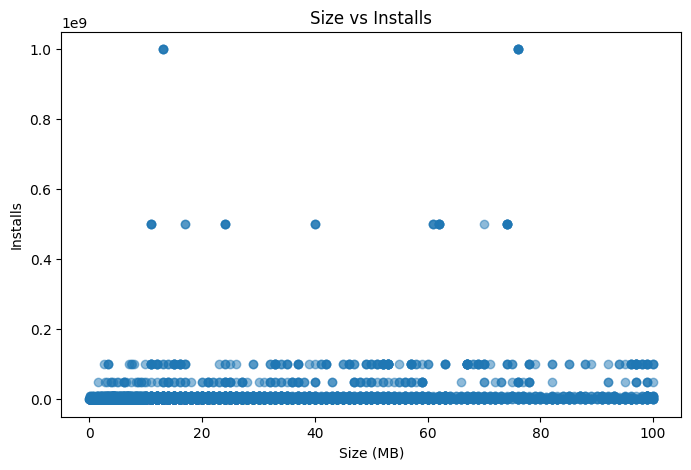

In [83]:
correlation = data["Size"].corr(data["Installs"])

print("Correlation:", round(correlation,3))

plt.figure(figsize=(8,5))
plt.scatter(data["Size"], data["Installs"], alpha=0.5)
plt.xlabel("Size (MB)")
plt.ylabel("Installs")
plt.title("Size vs Installs")
plt.show()

Correlation: -0.01


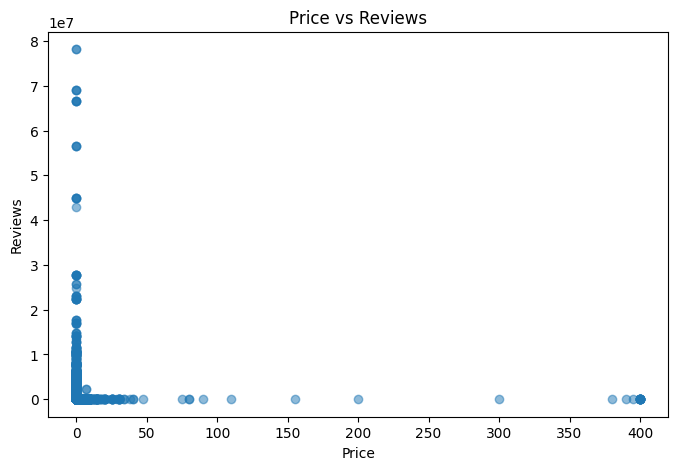

In [84]:
correlation = data["Price"].corr(data["Reviews"])

print("Correlation:", round(correlation,3))

plt.figure(figsize=(8,5))
plt.scatter(data["Price"], data["Reviews"], alpha=0.5)
plt.xlabel("Price")
plt.ylabel("Reviews")
plt.title("Price vs Reviews")
plt.show()

Correlation: -0.001


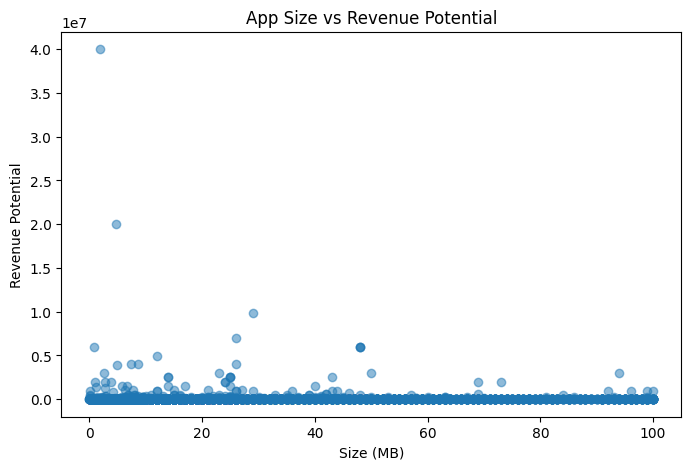

In [85]:
data["Revenue_Potential"] = data["Price"] * data["Installs"]

correlation = data["Size"].corr(data["Revenue_Potential"])

print("Correlation:", round(correlation,3))

plt.figure(figsize=(8,5))
plt.scatter(data["Size"], data["Revenue_Potential"], alpha=0.5)
plt.xlabel("Size (MB)")
plt.ylabel("Revenue Potential")
plt.title("App Size vs Revenue Potential")
plt.show()

Do free and paid apps have significantly different ratings?

Average Rating of Free Apps : 4.19
Average Rating of Paid Apps : 4.27


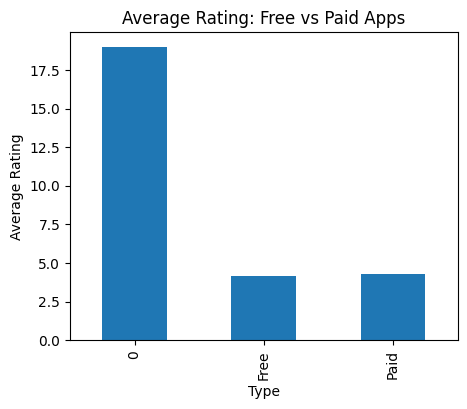

In [86]:
free_rating = data[data["Type"] == "Free"]["Rating"].mean()
paid_rating = data[data["Type"] == "Paid"]["Rating"].mean()

print("Average Rating of Free Apps :", round(free_rating, 2))
print("Average Rating of Paid Apps :", round(paid_rating, 2))

data.groupby("Type")["Rating"].mean().plot(kind="bar", figsize=(5,4))
plt.title("Average Rating: Free vs Paid Apps")
plt.ylabel("Average Rating")
plt.show()

Are Type and Content Rating independent?

Content Rating  Adults only 18+  Everyone  Everyone 10+  Mature 17+  Teen  \
Type                                                                        
Free                          3      8019           380         479  1156   
Paid                          0       695            33          20    52   

Content Rating  Unrated  
Type                     
Free                  2  
Paid                  0  


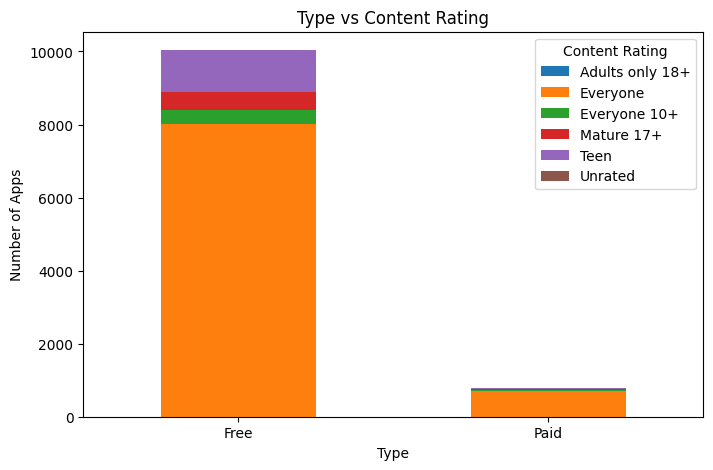

In [87]:
cross_tab = pd.crosstab(data["Type"], data["Content Rating"])

print(cross_tab)

cross_tab.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Type vs Content Rating")
plt.xlabel("Type")
plt.ylabel("Number of Apps")
plt.xticks(rotation=0)
plt.show()

Create a Revenue Potential feature
use Revenue = Price × Installs

In [88]:
data["Revenue_Potential"] = data["Price"] * data["Installs"]

data[["App", "Price", "Installs", "Revenue_Potential"]].head()

,App,Price,Installs,Revenue_Potential
0,Photo Editor & Candy Camera & Grid & ScrapBook,0.0,10000.0,0.0
1,Coloring book moana,0.0,500000.0,0.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",0.0,5000000.0,0.0
3,Sketch - Draw & Paint,0.0,50000000.0,0.0
4,Pixel Draw - Number Art Coloring Book,0.0,100000.0,0.0


Which category has the highest revenue potential?

Category
FAMILY             1.860526e+08
LIFESTYLE          5.758394e+07
GAME               4.098764e+07
FINANCE            2.572668e+07
PHOTOGRAPHY        2.092277e+07
MEDICAL            1.357484e+07
PERSONALIZATION    1.027695e+07
TOOLS              5.464821e+06
SPORTS             4.706212e+06
PRODUCTIVITY       4.313375e+06
Name: Revenue_Potential, dtype: float64


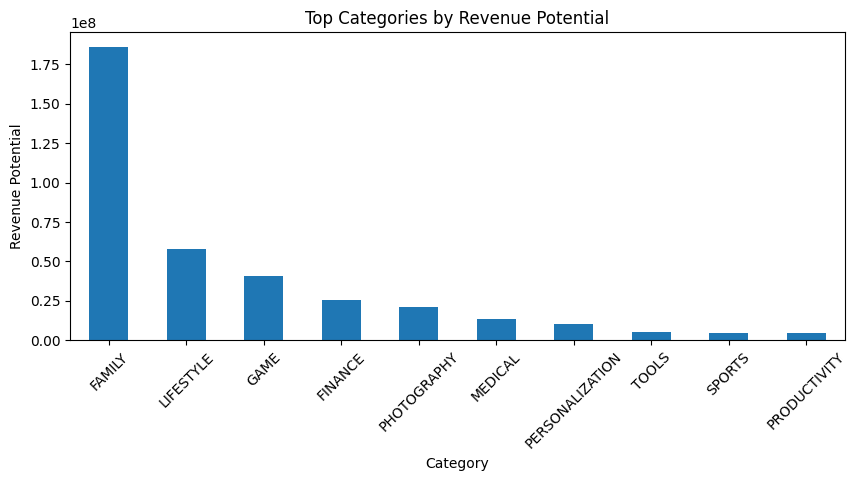

In [89]:
revenue = (
    data.groupby("Category")["Revenue_Potential"]
    .sum()
    .sort_values(ascending=False)
)

print(revenue.head(10))

revenue.head(10).plot(kind="bar", figsize=(10,4))
plt.title("Top Categories by Revenue Potential")
plt.xlabel("Category")
plt.ylabel("Revenue Potential")
plt.xticks(rotation=45)
plt.show()

Create a Review-to-Install Ratio:

Review_Ratio = Reviews / Installs



In [90]:
data["Review_Ratio"] = data["Reviews"] / data["Installs"]

data["Review_Ratio"] = data["Review_Ratio"].fillna(0)

data[["App", "Reviews", "Installs", "Review_Ratio"]].head()

,App,Reviews,Installs,Review_Ratio
0,Photo Editor & Candy Camera & Grid & ScrapBook,159.0,10000.0,0.015900
1,Coloring book moana,967.0,500000.0,0.001934
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",87510.0,5000000.0,0.017502
3,Sketch - Draw & Paint,215644.0,50000000.0,0.004313
4,Pixel Draw - Number Art Coloring Book,967.0,100000.0,0.009670


Which apps have the most engaged users?

In [91]:
engaged_apps = (
    data.sort_values("Review_Ratio", ascending=False)
    [["App", "Review_Ratio", "Reviews", "Installs"]]
    .drop_duplicates(subset="App")
)

engaged_apps.head(20)

,App,Review_Ratio,Reviews,Installs
4550,RMEduS - 음성인식을 활용한 R 프로그래밍 실습 시스템,4.0000,4.0,1.0
2454,KBA-EZ Health Guide,4.0000,4.0,1.0
10697,Mu.F.O.,2.0000,2.0,1.0
5917,Ra Ga Ba,2.0000,2.0,1.0
5812,AX Watch for WatchMaker,2.0000,2.0,1.0
8591,DN Blog,2.0000,20.0,10.0
9096,DZ Puzzle,1.4000,14.0,10.0
6700,Brick Breaker BR,1.4000,7.0,5.0
6508,Sam.BN Pro,1.1000,11.0,10.0
7402,Trovami se ci riesci,1.1000,11.0,10.0


Create an App Age feature:

App_Age = Current Year − Last Updated Year

In [92]:
current_year = pd.Timestamp.now().year

data["App_Age"] = current_year - data["Year"]

data[["App", "Year", "App_Age"]].head()

,App,Year,App_Age
0,Photo Editor & Candy Camera & Grid & ScrapBook,2018.0,8.0
1,Coloring book moana,2018.0,8.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",2018.0,8.0
3,Sketch - Draw & Paint,2018.0,8.0
4,Pixel Draw - Number Art Coloring Book,2018.0,8.0


Do newer apps perform better?

           Rating      Installs
App_Age                        
8.0      4.244530  2.195282e+07
9.0      4.094793  2.180747e+06
10.0     4.041782  1.743154e+06
11.0     4.067268  9.249270e+05
12.0     4.037895  1.291657e+06
13.0     4.073404  9.381033e+05
14.0     3.785714  5.381619e+05
15.0     3.966667  1.160473e+06
16.0     4.200000  1.000000e+05


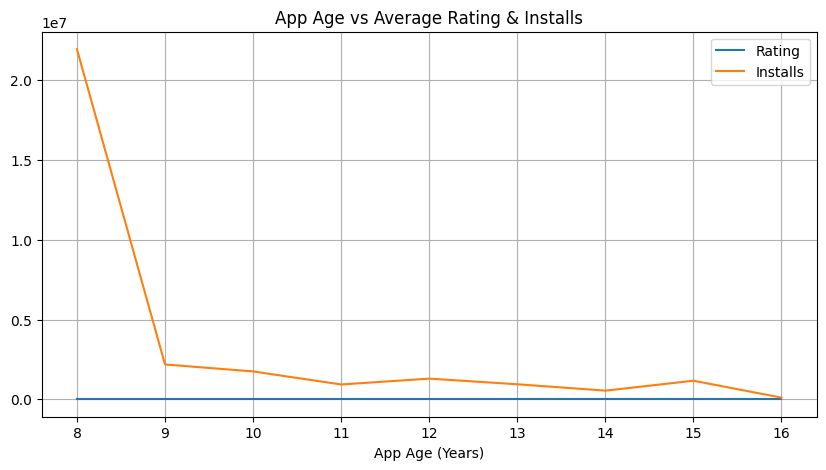

In [93]:
newer_apps = data.groupby("App_Age")[["Rating", "Installs"]].mean()

print(newer_apps)

newer_apps.plot(figsize=(10,5))
plt.title("App Age vs Average Rating & Installs")
plt.xlabel("App Age (Years)")
plt.grid(True)
plt.show()

Create a Success Index:

Success_Index =
0.2 × Normalized Rating +
0.4 × Normalized Installs +
0.3 × Normalized Reviews



In [94]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

data[["Rating_Norm","Installs_Norm","Reviews_Norm"]] = scaler.fit_transform(
    data[["Rating","Installs","Reviews"]]
)

data["Success_Index"] = (
    0.2*data["Rating_Norm"] +
    0.4*data["Installs_Norm"] +
    0.3*data["Reviews_Norm"]
)

data[["App","Success_Index"]].head()

,App,Success_Index
0,Photo Editor & Candy Camera & Grid & ScrapBook,0.034449
1,Coloring book moana,0.032426
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",0.043447
3,Sketch - Draw & Paint,0.059717
4,Pixel Draw - Number Art Coloring Book,0.036710


Which apps are the most successful?

In [95]:
top_success = data.sort_values(
    "Success_Index",
    ascending=False
)[["App","Category","Success_Index"]].drop_duplicates("App")

top_success.head(20)

,App,Category,Success_Index
2544,Facebook,SOCIAL,0.734444
381,WhatsApp Messenger,COMMUNICATION,0.703083
2604,Instagram,SOCIAL,0.694437
382,Messenger – Text and Video Chat for Free,COMMUNICATION,0.650763
1872,Subway Surfers,GAME,0.545309
3665,YouTube,VIDEO_PLAYERS,0.535141
2884,Google Photos,PHOTOGRAPHY,0.480570
391,Skype - free IM & video calls,COMMUNICATION,0.474686
411,Google Chrome: Fast & Secure,COMMUNICATION,0.473680
3223,Maps - Navigate & Explore,TRAVEL_AND_LOCAL,0.472115


Do free apps with in-app purchases (inferred from low price + high reviews) outperform truly free apps in terms of rating and installs?

In [96]:
pseudo_iap = data[
    (data["Price"] <= 1) &
    (data["Reviews"] > data["Reviews"].median())
]

print("Average Rating:", pseudo_iap["Rating"].mean())
print("Average Installs:", pseudo_iap["Installs"].mean())

pseudo_iap[["Rating","Installs"]].mean()

Average Rating: 4.27391304347826
Average Installs: 31764939.27893738


,0
Rating,4.273913e+00
Installs,3.176494e+07


Which categories show the steepest "update fatigue" — apps that were last updated 2+ years ago but still have high install counts?

Category
FAMILY                 92
GAME                   87
PERSONALIZATION        35
TOOLS                  35
PRODUCTIVITY           22
PHOTOGRAPHY            21
COMMUNICATION          15
VIDEO_PLAYERS          11
LIBRARIES_AND_DEMO      9
SOCIAL                  8
LIFESTYLE               8
SPORTS                  7
HOUSE_AND_HOME          7
EDUCATION               7
HEALTH_AND_FITNESS      5
BOOKS_AND_REFERENCE     5
ENTERTAINMENT           5
WEATHER                 5
TRAVEL_AND_LOCAL        4
BUSINESS                3
FINANCE                 2
FOOD_AND_DRINK          1
BEAUTY                  1
MAPS_AND_NAVIGATION     1
NEWS_AND_MAGAZINES      1
Name: count, dtype: int64


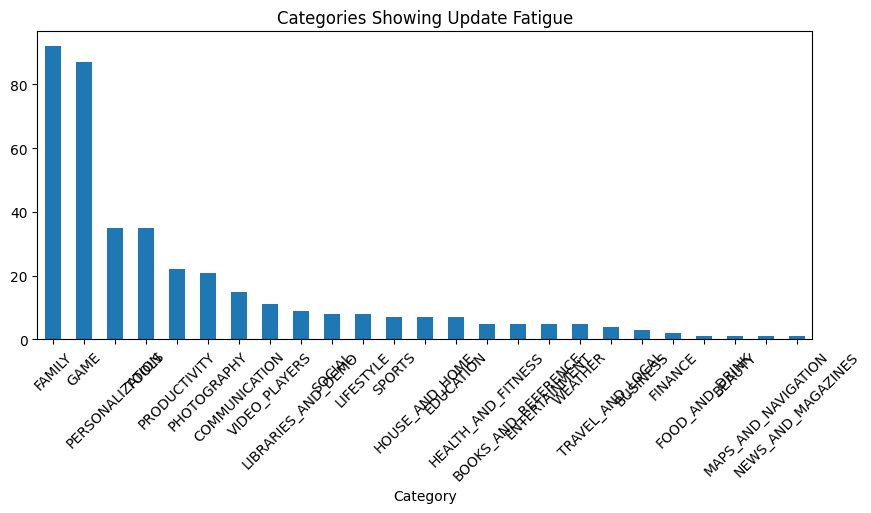

In [97]:
latest_year = data["Year"].max()

fatigue = data[
    (data["Year"] <= latest_year-2) &
    (data["Installs"] > data["Installs"].median())
]

fatigue_category = fatigue["Category"].value_counts()

print(fatigue_category)

fatigue_category.plot(kind="bar", figsize=(10,4))
plt.title("Categories Showing Update Fatigue")
plt.xticks(rotation=45)
plt.show()

Do apps that launched earlier (older Last Updated year) show declining ratings over time

App_Age
8.0     4.244530
9.0     4.094793
10.0    4.041782
11.0    4.067268
12.0    4.037895
13.0    4.073404
14.0    3.785714
15.0    3.966667
16.0    4.200000
Name: Rating, dtype: float64


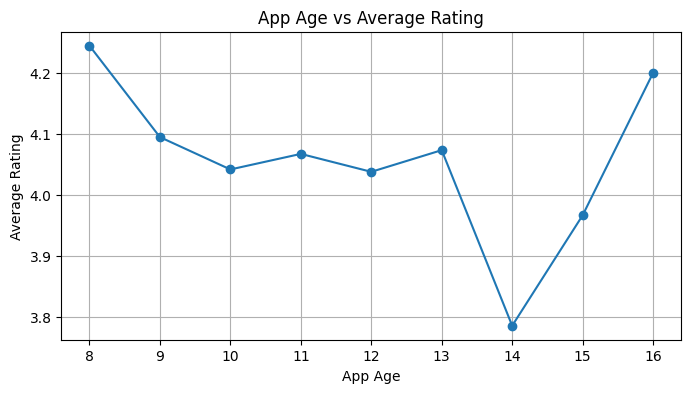

In [98]:
rating_age = data.groupby("App_Age")["Rating"].mean()

print(rating_age)

rating_age.plot(marker="o", figsize=(8,4))
plt.title("App Age vs Average Rating")
plt.xlabel("App Age")
plt.ylabel("Average Rating")
plt.grid(True)
plt.show()

# Thank You